In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda:4") if torch.cuda.is_available() else torch.device("cpu")
print(f"Working with {device}")

Working with cuda


In [ ]:
class MLP(nn.Module):
    def __init__(self, num_inputs, num_hiddens, num_outputs, num_layers):
        super().__init__()
        self.input_layer = nn.Linear(num_inputs, num_hiddens)        
        hidden_layers = []
        for _ in range(num_layers):
            hidden_layers.append(nn.Linear(num_hiddens, num_hiddens))
        self.hidden_layers = nn.ModuleList(hidden_layers)
        self.output_layer = nn.Linear(num_hiddens, num_outputs)

    def forward(self, x):
        x = F.silu(self.input_layer(x))
        for layer in self.hidden_layers:
            x = F.silu(layer(x))
        x = F.log_softmax(self.output_layer(x), -1)
        return x

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader


class FastMNIST(datasets.MNIST):
    def __init__(self, *args, **kwargs):
        num_data = kwargs.pop("num_data", None)
        super().__init__(*args, **kwargs)

        self.data = self.data.float().div(255).reshape(-1, 784)
        if num_data is not None:
            self.data, self.targets = self.data[:num_data], self.targets[:num_data]
        self.data, self.targets = self.data.to(device), self.targets.to(device)

    def __getitem__(self, index):
        return self.data[index], self.targets[index]


class FastFashionMNIST(datasets.FashionMNIST):
    def __init__(self, *args, **kwargs):
        num_data = kwargs.pop("num_data", None)
        super().__init__(*args, **kwargs)

        self.data = self.data.float().div(255).reshape(-1, 784)
        if num_data is not None:
            self.data, self.targets = self.data[:num_data], self.targets[:num_data]
        self.data, self.targets = self.data.to(device), self.targets.to(device)

    def __getitem__(self, index):
        return self.data[index], self.targets[index]


num_train = 5000
train_batch_size = 100
test_batch_size = 1000

training_data = FastMNIST(root="./data", train=True, download=True, num_data=num_train)
test_data = FastMNIST(root="./data", train=False, download=True)
train_dataloader = DataLoader(
    training_data, batch_size=train_batch_size, shuffle=True, num_workers=0
)
test_dataloader = DataLoader(test_data, batch_size=test_batch_size, num_workers=0)

ood_data = FastFashionMNIST(root="./data", download=True, train=False)
ood_dataloader = DataLoader(ood_data, batch_size=test_batch_size, num_workers=0)


In [ ]:
from sghmc import SGHMC, CyclicCosineDecayLR
from evaluation import accuracy
import matplotlib.pyplot as plt
from copy import deepcopy

num_inputs = 784
num_outputs = 10
num_hiddens = 128
num_layers = 2

burn_in_cycles = 20
num_cycles = 40

train_num_batches = len(train_dataloader)
test_num_batches = len(test_dataloader)
num_epochs_per_cycle = 30
num_steps_per_cycle = train_num_batches * num_epochs_per_cycle
total_num_epochs = num_cycles * num_epochs_per_cycle
total_num_steps = num_cycles * num_steps_per_cycle


def run_sghmc(
    lr=5.0e-2, momentum_decay=0.9, weight_decay=1.0e-3, temperature=1.0
):
    model = MLP(num_inputs, num_hiddens, num_outputs, num_layers).to(device)

    opt = SGHMC(
        model.parameters(),
        num_train,
        lr=lr,
        momentum_decay=momentum_decay,
        weight_decay=weight_decay,
        temperature=temperature,
    )

    scheduler = CyclicCosineDecayLR(
        opt,
        init_decay_epochs=num_steps_per_cycle,
        min_decay_lr=1.0e-4,
        restart_interval=num_steps_per_cycle,
        restart_lr=lr,
    )

    samples = []
    for cycle in range(1, num_cycles + 1):
        for epoch in range(num_epochs_per_cycle):

            model.train()
            train_acc = 0.0
            train_nll = 0.0
            for x, y in train_dataloader:
                opt.zero_grad()
                pred_logits = model(x)
                loss = F.cross_entropy(pred_logits, y)
                loss.backward()
                opt.step()
                scheduler.step()

                train_acc += accuracy(pred_logits, y).item()
                train_nll += loss.item()

            train_acc /= train_num_batches
            train_nll /= train_num_batches

        if cycle % 10 == 0:
            model.eval()
            with torch.no_grad():
                test_acc = 0.0
                test_nll = 0.0
                for x, y in test_dataloader:
                    pred_logits = model(x)
                    test_acc += accuracy(pred_logits, y)
                    test_nll += F.cross_entropy(pred_logits, y)

                test_acc /= test_num_batches
                test_nll /= test_num_batches
            print(
                f"Cycle {cycle} lr {scheduler.get_last_lr()[0]:.4f} "
                f"train: nll {train_nll:.4f} acc {train_acc:.4f} "
                f"test: nll {test_nll:.4f} acc {test_acc:.4f}"
            )

        if cycle > burn_in_cycles:
            samples.append(deepcopy(model.state_dict()))

    return samples

In [ ]:
temperatures = [1.0, 0.1, 0.01, 0.001]
samples = []
for temperature in temperatures:
    print(f"Running with temperature {temperature:.4f}...")
    samples.append(run_sghmc(temperature=temperature))

Running with temperature 1.0000...
Cycle 10 lr 0.0500 train: nll 0.0727 acc 0.9764 test: nll 0.9168 acc 0.8965
Cycle 20 lr 0.0500 train: nll 0.0734 acc 0.9768 test: nll 0.8413 acc 0.8981
Cycle 30 lr 0.0500 train: nll 0.0717 acc 0.9764 test: nll 0.7871 acc 0.8998
Cycle 40 lr 0.0500 train: nll 0.0662 acc 0.9804 test: nll 0.8223 acc 0.8935
Running with temperature 0.1000...
Cycle 10 lr 0.0500 train: nll 0.0058 acc 1.0000 test: nll 0.3229 acc 0.9274
Cycle 20 lr 0.0500 train: nll 0.0053 acc 1.0000 test: nll 0.2984 acc 0.9324
Cycle 30 lr 0.0500 train: nll 0.0059 acc 1.0000 test: nll 0.3009 acc 0.9331
Cycle 40 lr 0.0500 train: nll 0.0054 acc 0.9998 test: nll 0.2951 acc 0.9324
Running with temperature 0.0100...
Cycle 10 lr 0.0500 train: nll 0.0051 acc 1.0000 test: nll 0.2147 acc 0.9439
Cycle 20 lr 0.0500 train: nll 0.0048 acc 1.0000 test: nll 0.2070 acc 0.9453
Cycle 30 lr 0.0500 train: nll 0.0051 acc 1.0000 test: nll 0.2069 acc 0.9439
Cycle 40 lr 0.0500 train: nll 0.0052 acc 1.0000 test: nll 0

In [ ]:
from evaluation import evaluate

model = MLP(num_inputs, num_hiddens, num_outputs, num_layers).to(device)
metrics = []
for samples_ in samples:
    
    pred_logits = []
    ood_pred_logits = []

    with torch.no_grad():
        for sample in samples_:
            model.load_state_dict(sample)
            pred_logits_ = []
            for x, _ in test_dataloader:
                pred_logits_.append(model(x))
            pred_logits.append(torch.cat(pred_logits_, 0))

            ood_pred_logits_ = []
            for x, _ in ood_dataloader:
                ood_pred_logits_.append(model(x))
            ood_pred_logits.append(torch.cat(ood_pred_logits_, 0))

    pred_logits = torch.stack(pred_logits, 0)
    ood_pred_logits = torch.stack(ood_pred_logits, 0)

    metrics.append(evaluate(pred_logits, ood_pred_logits, test_data.targets))

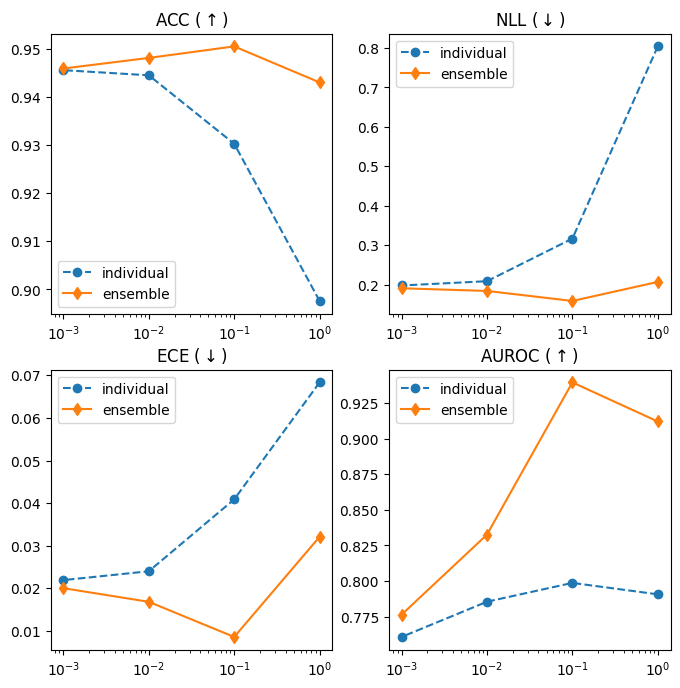

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.subplot(221)
plt.title(r"ACC ($\uparrow$)")
plt.plot(temperatures, [metrics_["indiv"]["acc"] for metrics_ in metrics], '--o', label="individual")
plt.plot(temperatures, [metrics_["ens"]["acc"] for metrics_ in metrics], '-d', label="ensemble")
plt.legend()
plt.xscale("log")

plt.subplot(222)
plt.title(r"NLL ($\downarrow$)")
plt.plot(temperatures, [metrics_["indiv"]["nll"] for metrics_ in metrics], '--o', label="individual")
plt.plot(temperatures, [metrics_["ens"]["nll"] for metrics_ in metrics], '-d', label="ensemble")
plt.legend()
plt.xscale("log")

plt.subplot(223)
plt.title(r"ECE ($\downarrow$)")
plt.plot(temperatures, [metrics_["indiv"]["ece"] for metrics_ in metrics], '--o', label="individual")
plt.plot(temperatures, [metrics_["ens"]["ece"] for metrics_ in metrics], '-d', label="ensemble")
plt.legend()
plt.xscale("log")

plt.subplot(224)
plt.title(r"AUROC ($\uparrow$)")
plt.plot(temperatures, [metrics_["indiv"]["auroc"] for metrics_ in metrics], '--o', label="individual")
plt.plot(temperatures, [metrics_["ens"]["auroc"] for metrics_ in metrics], '-d', label="ensemble")
plt.legend()
plt.xscale("log")